In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
from dotenv import load_dotenv
load_dotenv()

In [ ]:
import sys
BASE_PATH = os.environ.get("BASE_PATH")
sys.path.append(os.environ.get("BASE_PATH")) # type: ignore
from utils.visualization_utils import set_labels 
from utils.visualization_utils import highlight_max_bar

*Bivariate Analysis Questions*

Store & State Analysis — df_merged

* What are the total sales per state (CA, TX, WI)?
* What are the top-selling items per store?
* Are there significant differences in sales between stores within the same state?

Category & SNAP Analysis — df_merged

* What are the total sales per category (FOOD, HOBBIES, HOUSEHOLD)?
* How do SNAP days affect sales in the FOOD category?
* Does the SNAP effect vary across states?

Time Patterns — time_features.parquet + df_merged

* What is the monthly sales trend over the years?
* Is there a difference in sales between weekdays and weekends?
* Which month has the highest sales, and which has the lowest?

Price Analysis — price_features.parquet

* Is there a relationship between price changes and sales?
* What is the impact of price relative to the store average on sales?

In [ ]:
df = pd.read_parquet(f"{BASE_PATH}/data/processed/df_merged.parquet")
df_sample = df.sample(frac=0.1, random_state=42)  # 10% = ~5.9M row

In [4]:
df_sample.info(verbose=True)

<class 'pandas.DataFrame'>
Index: 5918109 entries, 50891010 to 2994966
Data columns (total 18 columns):
 #   Column             Dtype         
---  ------             -----         
 0   item_store_id      str           
 1   item_id            category      
 2   dept_id            category      
 3   cat_id             category      
 4   store_id           category      
 5   state_id           category      
 6   day_number         int16         
 7   sales              Int16         
 8   date               datetime64[us]
 9   walmart_year_week  int32         
 10  weekday            category      
 11  event_name         category      
 12  event_type         category      
 13  snap_CA            bool          
 14  snap_TX            bool          
 15  snap_WI            bool          
 16  month_name         category      
 17  sell_price         float32       
dtypes: Int16(1), bool(3), category(9), datetime64[us](1), float32(1), int16(1), int32(1), str(1)
memory usage: 445.

### Store & State Analysis

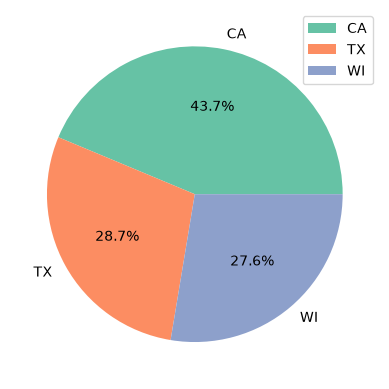

In [ ]:
# top sales per state
top_sales = df_sample.groupby('state_id')['sales'].sum()
from utils.visualization_utils import COLORS
fig, ax = plt.subplots()
plt.pie(
    x=top_sales,
    autopct="%1.1f%%",
    labels=df_sample['state_id'].value_counts().index, # type: ignore
    colors=COLORS
    )
plt.legend()
plt.show()

In [6]:
df_sample['store_id'].unique()

['CA_2', 'WI_1', 'WI_2', 'CA_4', 'CA_3', 'TX_3', 'CA_1', 'TX_2', 'TX_1', 'WI_3']
Categories (10, str): ['CA_1', 'CA_2', 'CA_3', 'CA_4', ..., 'TX_3', 'WI_1', 'WI_2', 'WI_3']

#### Observations

* **California (CA)** accounts for the largest share of total sales, contributing **43.7%**.
* **Texas (TX)** ranks second, representing **28.7%** of total sales.
* **Wisconsin (WI)** ranks third with **27.6%** of total sales.
* It is worth noting that **California has four stores**, whereas **Texas and Wisconsin each have three stores**. This larger store count may partially explain California's higher sales contribution.

In [7]:
df_sample['item_id'].head()

50891010      HOBBIES_1_156
23714387        FOODS_3_090
11522027        FOODS_3_681
52452520    HOUSEHOLD_1_009
34678172        FOODS_2_068
Name: item_id, dtype: category
Categories (3049, str): ['FOODS_1_001', 'FOODS_1_002', 'FOODS_1_003', 'FOODS_1_004', ..., 'HOUSEHOLD_2_513', 'HOUSEHOLD_2_514', 'HOUSEHOLD_2_515', 'HOUSEHOLD_2_516']

In [8]:
# Count sales of each item within each store
item_counts = (
    df_sample
    .groupby(['store_id', 'item_id'])
    .size()
    .reset_index(name='sales')
)

# Get the top-selling item for each store
top_item_per_store = (
    item_counts
    .sort_values('sales', ascending=False)
    .groupby('store_id')
    .first()
    .reset_index()
)
top_item_per_store["label"] = (
    top_item_per_store["store_id"].astype(str) + "  " + top_item_per_store["item_id"].astype(str)
)
top_item_per_store

,store_id,item_id,sales,label
0,CA_1,FOODS_1_214,239,CA_1 FOODS_1_214
1,CA_2,HOUSEHOLD_1_102,244,CA_2 HOUSEHOLD_1_102
2,CA_3,HOBBIES_1_333,242,CA_3 HOBBIES_1_333
3,CA_4,FOODS_3_068,245,CA_4 FOODS_3_068
4,TX_1,HOUSEHOLD_2_209,236,TX_1 HOUSEHOLD_2_209
5,TX_2,HOBBIES_1_105,240,TX_2 HOBBIES_1_105
6,TX_3,HOUSEHOLD_2_307,243,TX_3 HOUSEHOLD_2_307
7,WI_1,HOUSEHOLD_2_359,237,WI_1 HOUSEHOLD_2_359
8,WI_2,FOODS_3_411,246,WI_2 FOODS_3_411
9,WI_3,HOUSEHOLD_1_427,240,WI_3 HOUSEHOLD_1_427


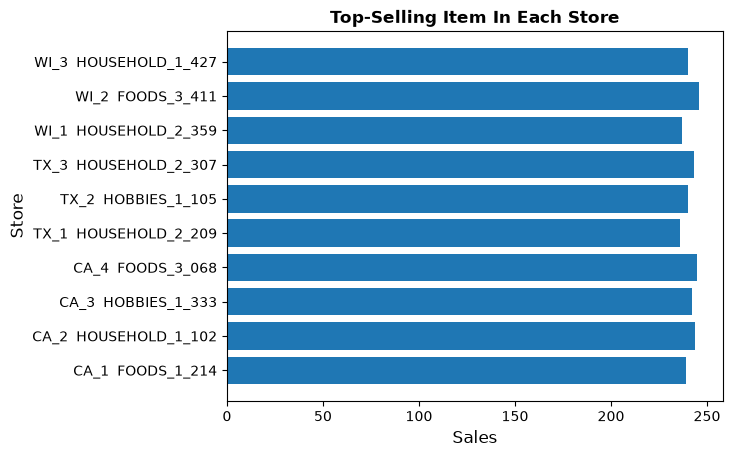

In [9]:
fig, ax = plt.subplots()
plt.barh(
    top_item_per_store["label"],
    top_item_per_store["sales"],
)
set_labels('Top-Selling Item in Each Store', 'Sales', "Store")
plt.show()

#### Observations

* The top-selling item is **different in every store**, indicating that customer demand varies across store locations.
* The highest-selling top item is **FOODS_3_411** in **WI_2**, with **246** sales.
* **CA_4** follows closely, where **FOODS_3_068** recorded **245** sales.
* The lowest top-selling item is **HOUSEHOLD_2_209** in **TX_1**, with **236** sales.
* The sales of the top-selling items are relatively consistent across stores, ranging from **236 to 246** units, suggesting similar demand levels among the best-performing products in each store.
* The top-selling items span all three major categories—**FOODS**, **HOUSEHOLD**, and **HOBBIES**—indicating that no single product category consistently dominates across all stores.


In [10]:
df_sample.info()

<class 'pandas.DataFrame'>
Index: 5918109 entries, 50891010 to 2994966
Data columns (total 18 columns):
 #   Column             Dtype         
---  ------             -----         
 0   item_store_id      str           
 1   item_id            category      
 2   dept_id            category      
 3   cat_id             category      
 4   store_id           category      
 5   state_id           category      
 6   day_number         int16         
 7   sales              Int16         
 8   date               datetime64[us]
 9   walmart_year_week  int32         
 10  weekday            category      
 11  event_name         category      
 12  event_type         category      
 13  snap_CA            bool          
 14  snap_TX            bool          
 15  snap_WI            bool          
 16  month_name         category      
 17  sell_price         float32       
dtypes: Int16(1), bool(3), category(9), datetime64[us](1), float32(1), int16(1), int32(1), str(1)
memory usage: 445.

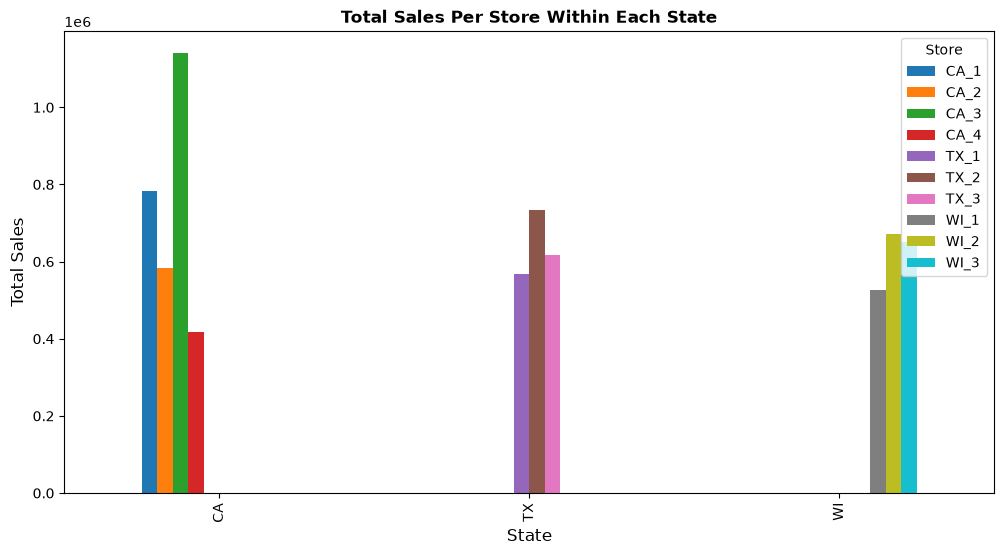

In [ ]:
state_store_sales = (
    df_sample
    .groupby(["state_id", "store_id"])["sales"]
    .sum()
    .reset_index()
)

fig, ax = plt.subplots(figsize=(12, 6))

state_store_sales.pivot(index="state_id", columns="store_id", values="sales").plot(
    kind="bar", ax=ax
)

ax.legend(title="Store")
set_labels("Total Sales per Store within Each State", "State", "Total Sales")

In [12]:
state_store_sales

,state_id,store_id,sales
0,CA,CA_1,782174
1,CA,CA_2,584026
2,CA,CA_3,1140653
3,CA,CA_4,416899
4,TX,TX_1,569090
5,TX,TX_2,732756
6,TX,TX_3,616477
7,WI,WI_1,525391
8,WI,WI_2,671317
9,WI,WI_3,650829


#### Observations

* **CA_3** is the top-performing store overall, generating **more than 1.14 million** in total sales. It significantly outperforms the other stores in California.
* Within **California**, **CA_1** ranks second with approximately **0.78 million** in total sales, while **CA_4** ranks fourth with around **0.41 million**, highlighting a substantial performance gap among the state's stores.
* In **Texas**, **TX_2** leads with approximately **0.73 million** in total sales, followed by **TX_3** with about **0.62 million**.
* In **Wisconsin**, **WI_3** is the highest-performing store, recording approximately **0.67 million** in total sales.
* Overall, **CA_3** stands out as the strongest-performing store across all states, while sales among the remaining top stores are relatively closer in comparison.



## Category & SNAP Analysis — df_merged

* What are the total sales per category (FOOD, HOBBIES, HOUSEHOLD)?
* How do SNAP days affect sales in the FOOD category?
* Does the SNAP effect vary across states?

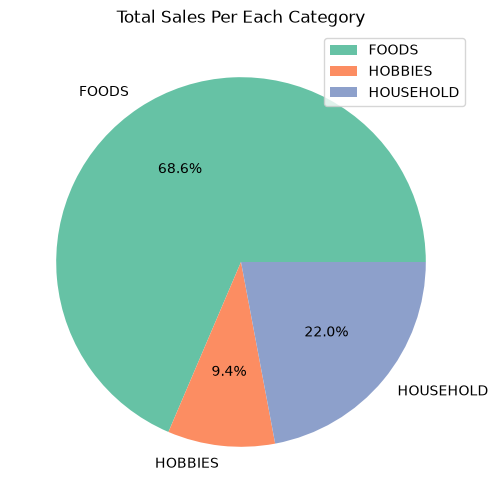

In [ ]:
total_sales_per_category = df_sample.groupby('cat_id')['sales'].sum()
plt.figure(figsize=(10,6))
plt.pie(
    x=total_sales_per_category,
    autopct='%1.1f%%',
    labels=total_sales_per_category.index, # type: ignore
    colors=COLORS
)
plt.title("Total Sales Per Each Category")
plt.legend(loc='upper right')
plt.show()

#### Observations

* **FOODS** is the dominant product category, accounting for **68.6%** of total sales.
* **HOUSEHOLD** ranks second, contributing **22.0%** of total sales.
* **HOBBIES** represents the smallest share, accounting for only **9.4%** of total sales.
* Overall, the **FOODS** category generates more than two-thirds of all sales, indicating that it is the primary driver of revenue.


In [14]:
# How do SNAP days affect sales in the FOOD category?
df_sample["is_snap"] = (
    ((df_sample["state_id"] == "CA") & df_sample["snap_CA"]) |
    ((df_sample["state_id"] == "TX") & df_sample["snap_TX"]) |
    ((df_sample["state_id"] == "WI") & df_sample["snap_WI"])
)

food_snap_sales = (
    df_sample[
        (df_sample["cat_id"] == "FOODS") &
        (df_sample["is_snap"])
    ]
    .groupby("state_id")["sales"]
    .sum()
)

food_snap_sales

state_id
CA    687573
TX    476677
WI    514840
Name: sales, dtype: Int64

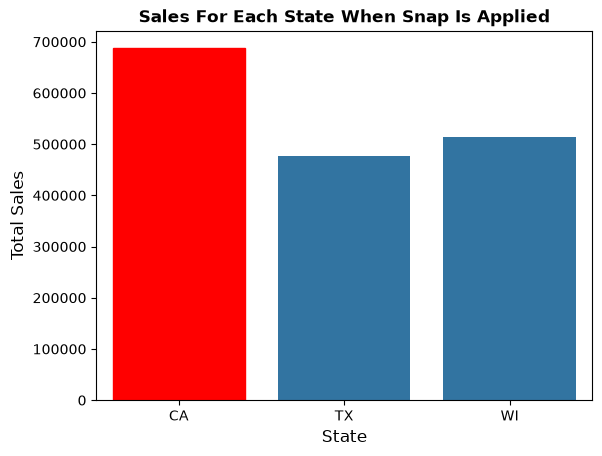

In [15]:
fig, ax = plt.subplots()
sns.barplot(
    x=food_snap_sales.index,
    y=food_snap_sales.values
)
highlight_max_bar(ax)
set_labels("Sales For Each State When Snap Is Applied", 'State', "Total Sales")
plt.show()

#### Observations: 
- When Snap is applied 
    - `CA` is leading with 0.68 million sales.
    - `WI` is second place with 0.51 million sales.
    - `TX` is third place with 0.47 million sales.

In [16]:
# How do SNAP days affect sales in the all categories
snap_sales = (
    df_sample[
        ((df_sample["cat_id"] == 'FOODS') | (df_sample["cat_id"] == 'HOBBIES') | (df_sample["cat_id"] == 'HOUSEHOLD')) &
        (df_sample["is_snap"])
    ]
    .groupby("state_id")["sales"]
    .sum()
)
snap_sales

state_id
CA    1016026
TX     678657
WI     691242
Name: sales, dtype: Int64

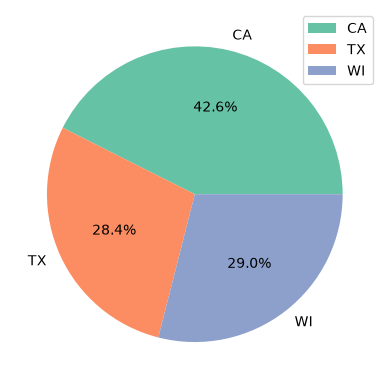

In [ ]:
plt.pie(
    x=snap_sales,
    autopct='%1.1f%%',
    labels=snap_sales.index, #type: ignore
    colors=COLORS
)
plt.legend(loc='upper right')
plt.show()

In [ ]:
time_features = pd.read_parquet(f'{BASE_PATH}/data/processed/time_features.parquet')
time_features.info()

<class 'pandas.DataFrame'>
RangeIndex: 59181090 entries, 0 to 59181089
Data columns (total 12 columns):
 #   Column             Dtype   
---  ------             -----   
 0   day_number         int16   
 1   walmart_year_week  int32   
 2   month_name         category
 3   weekday            category
 4   year               int16   
 5   month              int16   
 6   week               int16   
 7   day                int16   
 8   quarter            int16   
 9   is_weekend         bool    
 10  is_month_start     bool    
 11  is_month_end       bool    
dtypes: bool(3), category(2), int16(6), int32(1)
memory usage: 1.2 GB


In [19]:
time_features = time_features.drop_duplicates(subset=['day_number'])

## Time Features


In [20]:
# merge df_merged with time_features
result = df_sample.merge(
    time_features,
    how="left",
    on="day_number"
)

* What is the monthly sales trend over the years?
* Is there a difference in sales between weekdays and weekends?
* Which month has the highest sales, and which has the lowest?


In [21]:
result.drop(columns=['date'], inplace=True)

In [ ]:
result.drop(columns=["date", "walmart_year_week_y", "month_name_y", "weekday_y"], inplace=True)

In [23]:
result.rename(columns={
    "walmart_year_week_x": "walmart_year_week",
    "month_name_x": "month_name",
    "weekday_x": "weekday"
}, inplace=True)

In [24]:
result.info()

<class 'pandas.DataFrame'>
RangeIndex: 5918109 entries, 0 to 5918108
Data columns (total 26 columns):
 #   Column             Dtype   
---  ------             -----   
 0   item_store_id      str     
 1   item_id            category
 2   dept_id            category
 3   cat_id             category
 4   store_id           category
 5   state_id           category
 6   day_number         int16   
 7   sales              Int16   
 8   walmart_year_week  int32   
 9   weekday            category
 10  event_name         category
 11  event_type         category
 12  snap_CA            bool    
 13  snap_TX            bool    
 14  snap_WI            bool    
 15  month_name         category
 16  sell_price         float32 
 17  is_snap            bool    
 18  year               int16   
 19  month              int16   
 20  week               int16   
 21  day                int16   
 22  quarter            int16   
 23  is_weekend         bool    
 24  is_month_start     bool    
 25  is

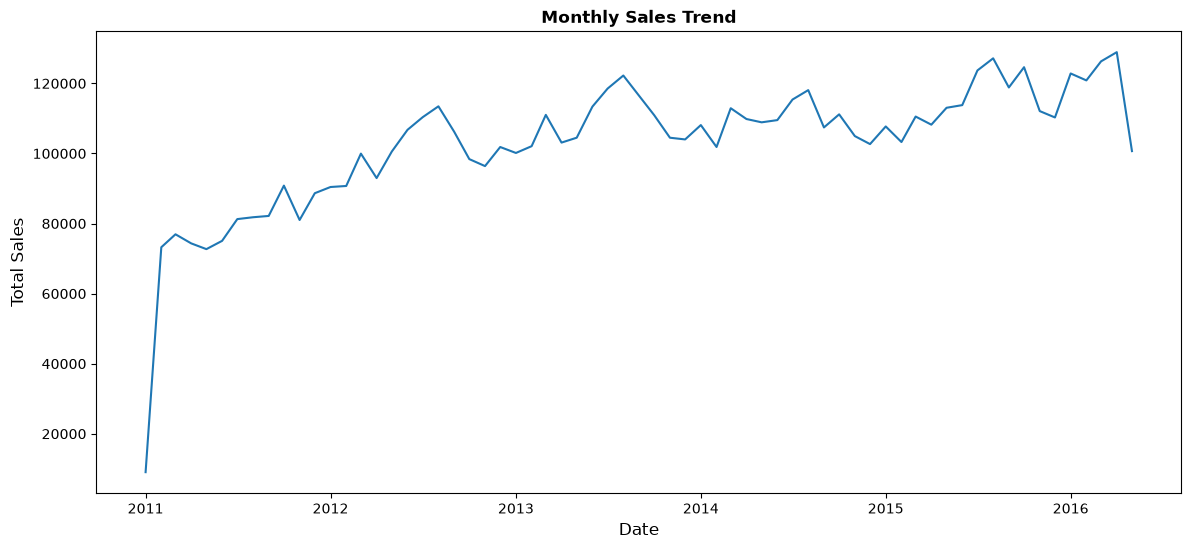

In [25]:
# What is the monthly sales trend over the years?
monthly_sales = (
    result
    .groupby(["year", "month"])["sales"]
    .sum()
    .reset_index()
)

monthly_sales["date"] = pd.to_datetime(monthly_sales[["year", "month"]].assign(day=1))

fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(monthly_sales["date"], monthly_sales["sales"])
set_labels("Monthly Sales Trend", "Date", "Total Sales")

#### Observations

* Total sales exhibit a clear upward trend over the five-year period, increasing from **less than 20,000** in early **2011** to approximately **130,000** by early **2016**.
* The most significant increase occurs during the first few months of **2011**, where total sales rise sharply from their lowest level to more than **70,000**.
* Sales display recurring peaks and troughs throughout the period, indicating a strong seasonal pattern rather than a steady linear increase.
* Despite these short-term fluctuations, the overall trend remains consistently upward, reflecting sustained growth in sales over time.


In [26]:
# Is there a difference in sales between weekdays and weekends?
weekend_sales = (
    result.groupby('is_weekend')['sales']
    .sum()
    .reset_index()
)

weekend_sales

,is_weekend,sales
0,False,4371560
1,True,2318052


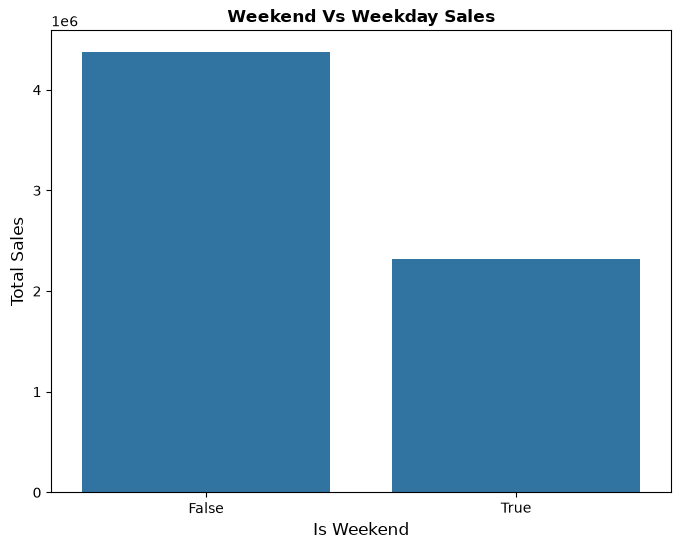

In [27]:
fig, ax = plt.subplots(figsize=(8, 6))
sns.barplot(data=weekend_sales, x='is_weekend', y='sales', ax=ax)
set_labels("Weekend vs Weekday Sales", "Is Weekend", "Total Sales")
plt.show()

In [28]:
# Which month has the highest sales, and which has the lowest?
highest_sales_per_month = (
    result.groupby('month_name')['sales']
    .sum()
    .reset_index()
    )

highest_sales_per_month

,month_name,sales
0,April,617383
1,August,562734
2,December,507461
3,February,591999
4,January,538259
5,July,549251
6,June,518509
7,March,637648
8,May,600345
9,November,498957


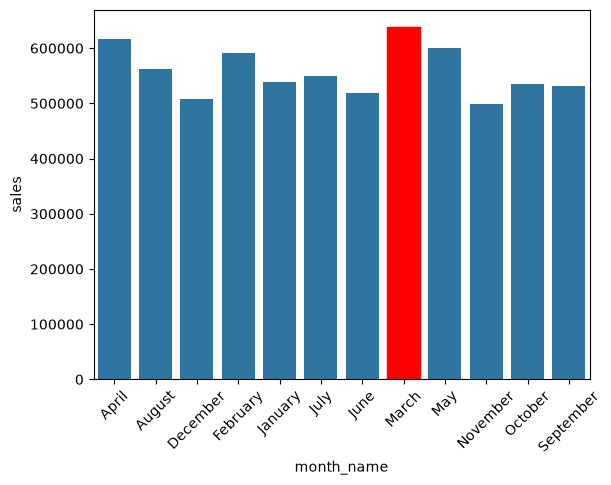

In [29]:
fig, ax = plt.subplots()
sns.barplot(data=highest_sales_per_month, x='month_name', y='sales', ax=ax)
plt.xticks(rotation=45)
highlight_max_bar(ax)
plt.show()

#### Observations
- March recorded the highest monthly sales with 637,648, making it the best-performing month.
- November had the lowest sales at 498,957, followed closely by December with 507,461.
- Sales remained relatively consistent throughout the year, ranging from approximately 499K to 638K, with stronger performance during March–May.

In [ ]:
price_features = pd.read_parquet(f'{BASE_PATH}/data/processed/price_features.parquet')

In [31]:
price_features.drop_duplicates(subset=["item_store_id", "day_number"], inplace=True)

In [ ]:

price_result = df_sample.merge(price_features, how="left", on=["item_store_id", "day_number"])

In [ ]:
# Q1: price_change vs sales
fig, ax = plt.subplots(figsize=(10, 6))
ax.scatter(price_result["price_change"], price_result["sales"], alpha=0.3, s=5)
set_labels("Price Change vs Sales", "Price Change", "Sales")

In [ ]:
# Q2: price_relative_to_store vs sales
fig, ax = plt.subplots(figsize=(10, 6))
ax.scatter(price_result["price_relative_to_store"], price_result["sales"], alpha=0.3, s=5)
set_labels("Price Relative to Store vs Sales", "Price Relative to Store", "Sales")